## Setup and Data
Semi-annual passive share series (Bloomberg, 2012-H1 to 2025-H1) with Chinco & Sammon (2024) scaling factor of 1.58.

In [2]:
# ── 04_arima: Setup & Data ───────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Capstone colour palette ──────────────────────────────────────────────────
# Consistent across all notebooks. IE University blue-anchored.
# CVD-safe: blue↔orange core pair avoids red-green confusion.
PAL = {
    'navy':    '#1B4F72',   # median lines, titles, emphasis
    'blue':    '#2E86C1',   # inflows, secondary lines, forecast
    'sky':     '#AED6F1',   # IQR / 80% CI bands
    'ice':     '#D6EAF8',   # 95% CI bands, backgrounds
    'amber':   '#E67E22',   # outflows, warnings, comparisons
    'brick':   '#C0392B',   # stress scenarios, crossover alert
    'fern':    '#27AE60',   # buybacks / positive offset (sparse)
    'charcoal':'#2C3E50',   # axis text, titles
    'slate':   '#7F8C8D',   # gridlines, secondary text
    'silver':  '#BDC3C7',   # axis spines
    'cloud':   '#F2F3F4',   # figure background
}

# ── Matplotlib defaults ──────────────────────────────────────────────────────
mpl.rcParams.update({
    'figure.facecolor':   PAL['cloud'],
    'axes.facecolor':     'white',
    'axes.edgecolor':     PAL['silver'],
    'axes.labelcolor':    PAL['charcoal'],
    'axes.titlesize':     13,
    'axes.titleweight':   'bold',
    'axes.titlecolor':    PAL['navy'],
    'axes.labelsize':     10,
    'xtick.color':        PAL['slate'],
    'ytick.color':        PAL['slate'],
    'xtick.labelsize':    9,
    'ytick.labelsize':    9,
    'grid.color':         PAL['silver'],
    'grid.alpha':         0.4,
    'grid.linewidth':     0.5,
    'axes.grid':          False,
    'legend.fontsize':    9,
    'legend.framealpha':  0.9,
    'legend.edgecolor':   PAL['silver'],
    'font.family':        'sans-serif',
    'font.size':          10,
    'figure.dpi':         150,
    'savefig.dpi':        300,
    'savefig.bbox':       'tight',
})

# ── Helper: clean up chart spines ────────────────────────────────────────────
def clean_spines(ax):
    """Remove top & right spines, lighten bottom & left."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color(PAL['silver'])
    ax.spines['left'].set_color(PAL['silver'])

# ── Paths (notebook runs from /notebooks — data is one level up) ─────────────
PROC = r'..\data\processed'
OUT  = r'..\outputs'
os.makedirs(PROC, exist_ok=True)
os.makedirs(OUT, exist_ok=True)

# ── Passive share: Bloomberg narrow (% of total US equity market cap) ────────
# Source: Module 5 exploration (01_data_exploration.ipynb, Section 5)
# Computed as: Passive Equity AUM (Bloomberg BI) / US Equity Market Cap (FactSet)
# 27 semi-annual observations, 2012-H1 to 2025-H1

data = pd.DataFrame({
    'period': [
        '2012-H1','2012-H2','2013-H1','2013-H2','2014-H1','2014-H2',
        '2015-H1','2015-H2','2016-H1','2016-H2','2017-H1','2017-H2',
        '2018-H1','2018-H2','2019-H1','2019-H2','2020-H1','2020-H2',
        '2021-H1','2021-H2','2022-H1','2022-H2','2023-H1','2023-H2',
        '2024-H1','2024-H2','2025-H1'
    ],
    'bb_narrow_pct': [
        10.2, 11.0, 11.4, 11.8, 12.4, 12.8,
        13.7, 14.0, 15.0, 15.7, 17.1, 18.0,
        18.3, 19.3, 19.2, 19.7, 19.5, 18.5,
        18.6, 18.8, 20.1, 21.0, 20.9, 21.2,
        21.3, 21.4, 22.2
    ]
})

# Proper datetime index (semi-annual month-ends)
data.index = pd.date_range(start='2012-06-30', periods=len(data), freq='6ME')
data.index.name = 'date'

# C&S adjusted = Bloomberg narrow × 1.58 (Chinco & Sammon 2024)
CS_SCALING = 1.58      # Chinco & Sammon (2024): true passive share is 1.58x narrow Bloomberg measure
data['cs_adjusted_pct'] = data['bb_narrow_pct'] * CS_SCALING

print(f'Passive share series: {len(data)} semi-annual observations')
print(f"Period: {data['period'].iloc[0]} to {data['period'].iloc[-1]}")
print(f"Bloomberg narrow: {data['bb_narrow_pct'].iloc[0]:.1f}% → {data['bb_narrow_pct'].iloc[-1]:.1f}%")
print(f"C&S adjusted:     {data['cs_adjusted_pct'].iloc[0]:.1f}% → {data['cs_adjusted_pct'].iloc[-1]:.1f}%")
print(f"\nSemi-annual growth (full sample): {(data['bb_narrow_pct'].iloc[-1] - data['bb_narrow_pct'].iloc[0])/(len(data)-1):.3f} pp/half")
print(f"Annualized growth: {(data['bb_narrow_pct'].iloc[-1] - data['bb_narrow_pct'].iloc[0])/(len(data)-1)*2:.3f} pp/year")

Passive share series: 27 semi-annual observations
Period: 2012-H1 to 2025-H1
Bloomberg narrow: 10.2% → 22.2%
C&S adjusted:     16.1% → 35.1%

Semi-annual growth (full sample): 0.462 pp/half
Annualized growth: 0.923 pp/year


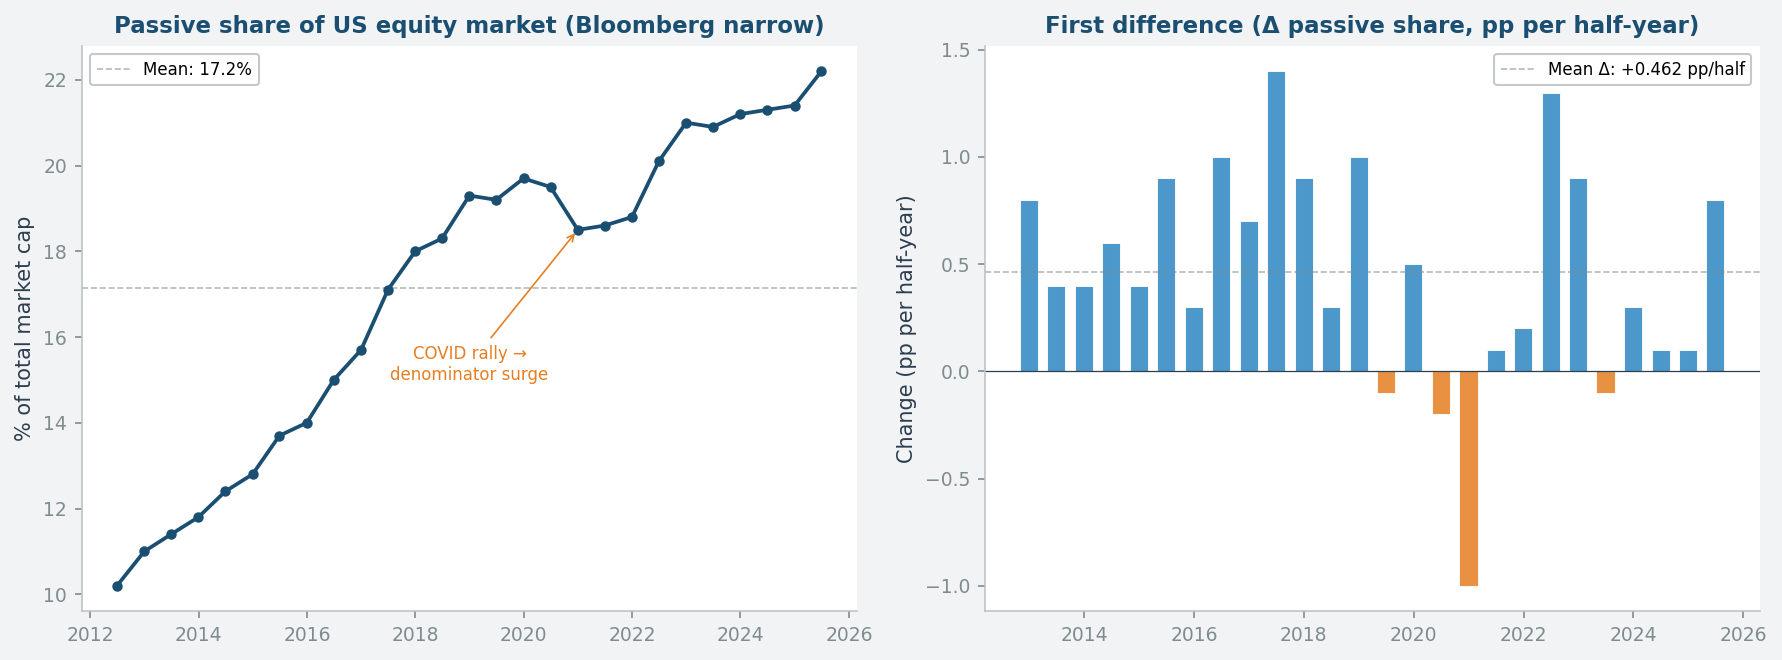

First difference statistics:
  Mean:   +0.462 pp/half  (+0.923 pp/year)
  Std:     0.522 pp/half
  Min:    -1.000 (2020-12)
  Max:    +1.400 (2017-06)

Key observation: 2019-2021 plateau/dip is the DENOMINATOR effect.
Market cap surged in COVID rally → ratio fell even as passive AUM grew.
This is real, not noise — the ARIMA will capture it via wider CIs.


In [3]:
# ── Visual Inspection ────────────────────────────────────────────────────────
# Chart message: "Strong upward trend with a 2019-2021 plateau caused by the
# COVID-era market cap surge (denominator effect), not a slowdown in passive adoption."

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ── Left: Level ──────────────────────────────────────────────────────────────
axes[0].plot(data.index, data['bb_narrow_pct'], 'o-', color=PAL['navy'],
             markersize=4, linewidth=1.8, zorder=5)
axes[0].axhline(y=data['bb_narrow_pct'].mean(), color=PAL['slate'], linestyle='--',
                alpha=0.6, linewidth=0.8, label=f"Mean: {data['bb_narrow_pct'].mean():.1f}%")
axes[0].annotate('COVID rally →\ndenominator surge',
                 xy=(pd.Timestamp('2020-12-30'), 18.5), fontsize=8, color=PAL['amber'],
                 ha='center', arrowprops=dict(arrowstyle='->', color=PAL['amber'], lw=0.8),
                 xytext=(pd.Timestamp('2019-01-01'), 15.0))
axes[0].set_title('Passive share of US equity market (Bloomberg narrow)', fontsize=11)
axes[0].set_ylabel('% of total market cap')
axes[0].legend(fontsize=8, framealpha=0.9)
clean_spines(axes[0])

# ── Right: First difference ──────────────────────────────────────────────────
diff = data['bb_narrow_pct'].diff().dropna()
bar_colors = [PAL['blue'] if v >= 0 else PAL['amber'] for v in diff.values]
axes[1].bar(diff.index, diff.values, width=120, color=bar_colors, alpha=0.85,
            edgecolor='white', linewidth=0.5)
axes[1].axhline(y=0, color=PAL['charcoal'], linewidth=0.6)
axes[1].axhline(y=diff.mean(), color=PAL['slate'], linestyle='--', alpha=0.6,
                linewidth=0.8, label=f"Mean Δ: {diff.mean():+.3f} pp/half")
axes[1].set_title('First difference (Δ passive share, pp per half-year)', fontsize=11)
axes[1].set_ylabel('Change (pp per half-year)')
axes[1].legend(fontsize=8, framealpha=0.9)
clean_spines(axes[1])

plt.tight_layout()
plt.savefig(f'{OUT}\\arima_visual_inspection.png', dpi=300, bbox_inches='tight')
plt.show()

# Hard numbers
print(f'First difference statistics:')
print(f"  Mean:   {diff.mean():+.3f} pp/half  ({diff.mean()*2:+.3f} pp/year)")
print(f"  Std:     {diff.std():.3f} pp/half")
print(f"  Min:    {diff.min():+.3f} ({diff.idxmin().strftime('%Y-%m')})")
print(f"  Max:    {diff.max():+.3f} ({diff.idxmax().strftime('%Y-%m')})")
print(f'\nKey observation: 2019-2021 plateau/dip is the DENOMINATOR effect.')
print(f'Market cap surged in COVID rally → ratio fell even as passive AUM grew.')
print(f'This is real, not noise — the ARIMA will capture it via wider CIs.')

## Stationarity Testing and Model Selection
ADF tests confirm d=1. Information criteria select ARIMA(0,1,0) with drift.

In [4]:
# ── Stationarity Testing ─────────────────────────────────────────────────────
# Formally justify d=1 for the ARIMA specification
# IMPORTANT: maxlag capped at 4 — with only 26 first-differenced obs,
# the default autolag can select too many lags and kill statistical power.

y = data['bb_narrow_pct']
MAXLAG = 4             # Conservative for N=27 semi-annual observations  # conservative for N=27

# ADF on levels
adf_level = adfuller(y, maxlag=MAXLAG, autolag='AIC')
print('ADF Test — LEVELS')
print(f'  Test statistic: {adf_level[0]:.4f}')
print(f'  p-value:        {adf_level[1]:.4f}')
print(f'  Lags used:      {adf_level[2]}')
print(f'  Nobs:           {adf_level[3]}')
print(f"  Conclusion:     {'Stationary (reject H0)' if adf_level[1] < 0.05 else 'NON-STATIONARY (fail to reject H0)'}")

print()

# ADF on first differences
y_diff = y.diff().dropna()
adf_diff = adfuller(y_diff, maxlag=MAXLAG, autolag='AIC')
print('ADF Test — FIRST DIFFERENCES')
print(f'  Test statistic: {adf_diff[0]:.4f}')
print(f'  p-value:        {adf_diff[1]:.4f}')
print(f'  Lags used:      {adf_diff[2]}')
print(f'  Nobs:           {adf_diff[3]}')
print(f"  Conclusion:     {'STATIONARY (reject H0) → d=1 justified' if adf_diff[1] < 0.05 else 'Marginal — see note below'}")

# Interpretation
print(f'\n── Interpretation ──')
if adf_level[1] >= 0.05 and adf_diff[1] < 0.05:
    print(f'Clean result: levels non-stationary, first differences stationary → d=1.')
elif adf_level[1] >= 0.05 and adf_diff[1] >= 0.05:
    print(f'ADF on differences has p={adf_diff[1]:.3f} — not rejected at 5%.')
    print(f'With only {len(y_diff)} obs, ADF has low power against near-unit-root alternatives.')
    print(f'Visual inspection clearly shows a trend in levels and mean-reverting differences.')
    print(f'Proceed with d=1 — standard for trended macro series with small samples.')
    print(f'KPSS test (H0: stationary) could provide complementary evidence if needed.')

ADF Test — LEVELS
  Test statistic: -1.6512
  p-value:        0.4564
  Lags used:      0
  Nobs:           26
  Conclusion:     NON-STATIONARY (fail to reject H0)

ADF Test — FIRST DIFFERENCES
  Test statistic: -3.7078
  p-value:        0.0040
  Lags used:      0
  Nobs:           25
  Conclusion:     STATIONARY (reject H0) → d=1 justified

── Interpretation ──
Clean result: levels non-stationary, first differences stationary → d=1.


In [5]:
# ── Model Selection: ARIMA(0,1,0) vs ARIMA(1,1,0) ───────────────────────────
# With only 27 obs, we cap complexity at p≤1, q=0, d=1
# trend='t' means a linear trend in the model, which for d=1 is equivalent to
# a constant drift in the differenced series

y = data['bb_narrow_pct']
results = {}

for order_label, order in [('ARIMA(0,1,0)', (0,1,0)), ('ARIMA(1,1,0)', (1,1,0))]:
    try:
        model = ARIMA(y, order=order, trend='t')
        fit = model.fit()
        results[order_label] = {
            'fit': fit,
            'aic': fit.aic,
            'bic': fit.bic,
            'sigma2': fit.params.get('sigma2', np.nan),
        }
        print(f"\n{'='*60}")
        print(f'  {order_label} with drift')
        print(f"{'='*60}")
        print(fit.summary().tables[1].as_text())
        print(f'  AIC: {fit.aic:.2f}  |  BIC: {fit.bic:.2f}')
    except Exception as e:
        print(f'{order_label}: FAILED — {e}')

# Compare
print(f"\n{'='*60}")
print('MODEL COMPARISON')
print(f"{'='*60}")
print(f"{'Model':<20} {'AIC':>10} {'BIC':>10}")
print(f"{'-'*40}")
for name, r in results.items():
    print(f"{name:<20} {r['aic']:>10.2f} {r['bic']:>10.2f}")

# Selection logic
if len(results) == 2:
    aic_diff = results['ARIMA(1,1,0)']['aic'] - results['ARIMA(0,1,0)']['aic']
    print(f'\nΔAIC (adding AR(1)): {aic_diff:+.2f}')
    if aic_diff < -2:
        selected = 'ARIMA(1,1,0)'
        print(f'→ AR(1) term improves fit substantially. Select ARIMA(1,1,0).')
    else:
        selected = 'ARIMA(0,1,0)'
        print(f'→ AR(1) term does not improve fit enough (ΔAIC > -2). Select simpler ARIMA(0,1,0).')
    print(f'\n★ SELECTED MODEL: {selected}')
else:
    selected = list(results.keys())[0]
    print(f'\n★ Only one model succeeded: {selected}')


  ARIMA(0,1,0) with drift
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.4615      0.106      4.350      0.000       0.254       0.669
sigma2         0.2616      0.066      3.963      0.000       0.132       0.391
  AIC: 42.92  |  BIC: 45.44

  ARIMA(1,1,0) with drift
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.4699      0.136      3.460      0.001       0.204       0.736
ar.L1          0.2475      0.254      0.974      0.330      -0.251       0.746
sigma2         0.2449      0.074      3.325      0.001       0.101       0.389
  AIC: 43.27  |  BIC: 47.05

MODEL COMPARISON
Model                       AIC        BIC
----------------------------------------
ARIMA(0,1,0)              42.92      45.44
ARIMA(1,1,0)              43.27   

In [6]:
# ── ITEM A2: ARIMA Model Comparison Table (Appendix) ────────────────
# Compare AIC/BIC across three candidate specifications.
# Paper reference: Section 4.12, "Appendix [X] reports information criteria."

from statsmodels.tsa.arima.model import ARIMA as ARIMA_cls

comparison = []
for order in [(0,1,0), (1,1,0), (0,1,1)]:
    try:
        m = ARIMA_cls(y, order=order, trend='t').fit()
        comparison.append({
            'Model': f'ARIMA{order}',
            'AIC': round(m.aic, 1),
            'BIC': round(m.bic, 1),
            'Log-L': round(m.llf, 1),
        })
        print(f'ARIMA{order}: AIC={m.aic:.1f}, BIC={m.bic:.1f}, Log-L={m.llf:.1f}')
    except Exception as e:
        print(f'ARIMA{order}: FAILED — {e}')

comp_df = pd.DataFrame(comparison)
print(f'\nModel Comparison Table:')
print(comp_df.to_string(index=False))

# Validation: ARIMA(0,1,0) should have lowest or near-lowest AIC
best_aic = comp_df.loc[comp_df['AIC'].idxmin(), 'Model']
print(f'\nBest AIC model: {best_aic}')
if best_aic != 'ARIMA(0, 1, 0)':
    delta = comp_df.loc[comp_df['Model']=='ARIMA(0, 1, 0)', 'AIC'].values[0] - comp_df['AIC'].min()
    print(f'  ΔAIC from best: {delta:.1f} (within 2 = acceptable for parsimony)')


ARIMA(0, 1, 0): AIC=42.9, BIC=45.4, Log-L=-19.5
ARIMA(1, 1, 0): AIC=43.3, BIC=47.0, Log-L=-18.6
ARIMA(0, 1, 1): AIC=43.6, BIC=47.4, Log-L=-18.8

Model Comparison Table:
         Model  AIC  BIC  Log-L
ARIMA(0, 1, 0) 42.9 45.4  -19.5
ARIMA(1, 1, 0) 43.3 47.0  -18.6
ARIMA(0, 1, 1) 43.6 47.4  -18.8

Best AIC model: ARIMA(0, 1, 0)


## Diagnostics
Ljung-Box residual autocorrelation tests and normality assessment.

Residuals: 26 observations (expected ~26 after differencing)
Residual mean: 0.0000, std: 0.5216
Residual range: [-1.462, 0.938]


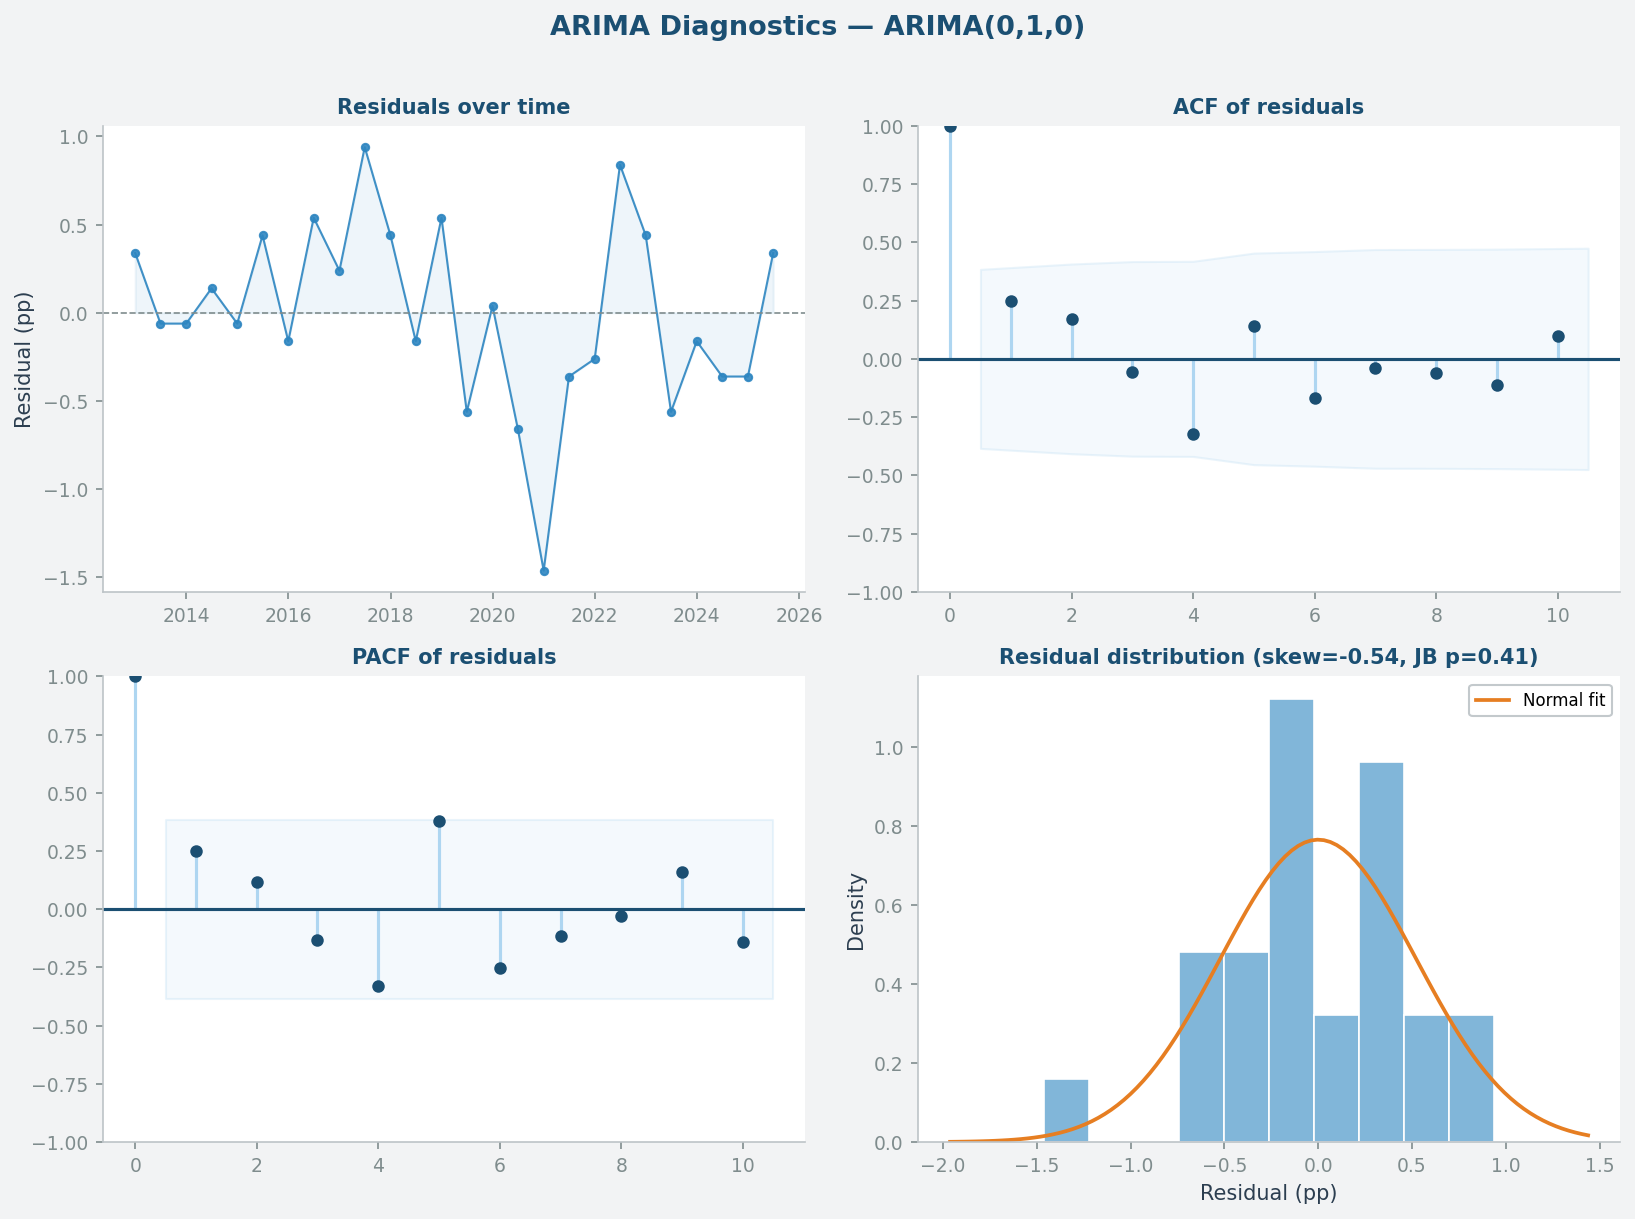


Ljung-Box Test (H0: no autocorrelation in residuals)
  Lag     Q-stat    p-value               Result
--------------------------------------------------
    4      6.231     0.1826 ✓ No autocorrelation
    8      8.150     0.4190 ✓ No autocorrelation
   12      9.344     0.6733 ✓ No autocorrelation

Normality diagnostics:
  Skewness:        -0.536
  Excess kurtosis: +0.704
  Jarque-Bera:     JB=1.780, p=0.4106
  → Residuals approximately normal ✓


In [7]:
# ── Diagnostics on Selected Model ────────────────────────────────────────────
best_fit = results[selected]['fit']
# Drop first residual — statsmodels initialization artifact, not a true forecast error
resid = best_fit.resid.iloc[1:]

# Check residual count
print(f'Residuals: {len(resid)} observations (expected ~{len(y)-1} after differencing)')
print(f'Residual mean: {resid.mean():.4f}, std: {resid.std():.4f}')
print(f'Residual range: [{resid.min():.3f}, {resid.max():.3f}]')

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# ── 1. Residuals over time ───────────────────────────────────────────────────
axes[0,0].plot(resid.index, resid.values, 'o-', color=PAL['blue'], markersize=3.5,
               linewidth=1, alpha=0.9)
axes[0,0].axhline(y=0, color=PAL['slate'], linewidth=0.8, linestyle='--')
axes[0,0].fill_between(resid.index, resid.values, 0, alpha=0.08, color=PAL['blue'])
axes[0,0].set_title('Residuals over time', fontsize=10)
axes[0,0].set_ylabel('Residual (pp)')
clean_spines(axes[0,0])

# ── 2. ACF of residuals ─────────────────────────────────────────────────────
plot_acf(resid, ax=axes[0,1], lags=10, alpha=0.05, title='',
         color=PAL['navy'], vlines_kwargs={'colors': PAL['navy']},
         markerfacecolor=PAL['navy'], markeredgecolor=PAL['navy'])
for item in axes[0,1].collections:
    item.set_facecolor(PAL['ice'])
    item.set_edgecolor(PAL['sky'])
axes[0,1].set_title('ACF of residuals', fontsize=10)
clean_spines(axes[0,1])

# ── 3. PACF of residuals ────────────────────────────────────────────────────
plot_pacf(resid, ax=axes[1,0], lags=10, alpha=0.05, title='', method='ywm',
          color=PAL['navy'], vlines_kwargs={'colors': PAL['navy']},
          markerfacecolor=PAL['navy'], markeredgecolor=PAL['navy'])
for item in axes[1,0].collections:
    item.set_facecolor(PAL['ice'])
    item.set_edgecolor(PAL['sky'])
axes[1,0].set_title('PACF of residuals', fontsize=10)
clean_spines(axes[1,0])

# ── 4. Histogram + normal curve (seaborn) ────────────────────────────────────
sns.histplot(resid, bins=10, color=PAL['blue'], alpha=0.6, edgecolor='white',
             linewidth=0.8, kde=False, stat='density', ax=axes[1,1])
x_range = np.linspace(resid.min() - 0.5, resid.max() + 0.5, 100)
axes[1,1].plot(x_range, stats.norm.pdf(x_range, resid.mean(), resid.std()),
               '-', color=PAL['amber'], linewidth=1.8, label='Normal fit')
# Data-driven title — always show both skewness and JB p-value
_jb, _jbp = stats.jarque_bera(resid)
_skew = stats.skew(resid)
_hist_title = f'Residual distribution (skew={_skew:+.2f}, JB p={_jbp:.2f})'
axes[1,1].set_title(_hist_title, fontsize=10)
axes[1,1].set_xlabel('Residual (pp)')
axes[1,1].legend(fontsize=8)
clean_spines(axes[1,1])

fig.suptitle(f'ARIMA Diagnostics — {selected}', fontsize=13, fontweight='bold',
             color=PAL['navy'], y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT}\\arima_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

# Ljung-Box test
lb = acorr_ljungbox(resid, lags=[4, 8, 12], return_df=True)
print('\nLjung-Box Test (H0: no autocorrelation in residuals)')
print(f"{'Lag':>5} {'Q-stat':>10} {'p-value':>10} {'Result':>20}")
print('-' * 50)
for lag, row in lb.iterrows():
    verdict = '✓ No autocorrelation' if row['lb_pvalue'] > 0.05 else '✗ Autocorrelation!'
    print(f"{lag:>5} {row['lb_stat']:>10.3f} {row['lb_pvalue']:>10.4f} {verdict:>20}")

# Jarque-Bera normality
jb_stat, jb_pval = stats.jarque_bera(resid)
skew = stats.skew(resid)
kurt = stats.kurtosis(resid, fisher=True)
print(f'\nNormality diagnostics:')
print(f'  Skewness:        {skew:+.3f}')
print(f'  Excess kurtosis: {kurt:+.3f}')
print(f'  Jarque-Bera:     JB={jb_stat:.3f}, p={jb_pval:.4f}')
if jb_pval > 0.05:
    print(f'  → Residuals approximately normal ✓')
else:
    print(f'  → Non-normal residuals (p={jb_pval:.4f}) — CIs are approximate.')
    print(f'    With only {len(resid)} obs, JB has limited reliability.')
    print(f'    ARIMA CIs remain valid asymptotically; interpret 95% bands conservatively.')

## Forecast: 2025-2050
Project passive share with 67% structural cap. Export annual values for the simulation.

In [8]:
# ── Forecast: 2025-H2 through 2050-H2 ───────────────────────────────────────
N_STEPS = 51  # 2025-H2 to 2050-H2 = 51 semi-annual periods
PASSIVE_CAP = 67.0  # Chinco & Sammon adjusted ceiling (see Section 4.12)

best_fit = results[selected]['fit']
forecast = best_fit.get_forecast(steps=N_STEPS)
fc_mean = forecast.predicted_mean
fc_ci_80 = forecast.conf_int(alpha=0.20)  # 80% CI
fc_ci_95 = forecast.conf_int(alpha=0.05)  # 95% CI

# Build forecast dates and period labels
fc_dates = []
fc_periods = []
start_year, start_half = 2025, 2  # first forecast = 2025-H2
for i in range(N_STEPS):
    yr = start_year + (start_half + i - 1) // 2
    h = ((start_half + i - 1) % 2) + 1
    month = '06' if h == 1 else '12'
    fc_dates.append(pd.Timestamp(f'{yr}-{month}-30'))
    fc_periods.append(f'{yr}-H{h}')

# Apply cap and floor
fc_mean_capped = np.minimum(fc_mean.values, PASSIVE_CAP)
fc_lower_80 = np.maximum(fc_ci_80.iloc[:, 0].values, 0)
fc_upper_80 = np.minimum(fc_ci_80.iloc[:, 1].values, PASSIVE_CAP)
fc_lower_95 = np.maximum(fc_ci_95.iloc[:, 0].values, 0)
fc_upper_95 = np.minimum(fc_ci_95.iloc[:, 1].values, PASSIVE_CAP)

# Build output DataFrame
forecast_df = pd.DataFrame({
    'period': fc_periods,
    'date': fc_dates,
    'bb_narrow_pct': fc_mean_capped,
    'bb_lower_80': fc_lower_80,
    'bb_upper_80': fc_upper_80,
    'bb_lower_95': fc_lower_95,
    'bb_upper_95': fc_upper_95,
})

# C&S adjusted (×1.58), capped at PASSIVE_CAP
for col in ['bb_narrow_pct', 'bb_lower_80', 'bb_upper_80', 'bb_lower_95', 'bb_upper_95']:
    cs_col = col.replace('bb_', 'cs_')
    forecast_df[cs_col] = np.minimum(forecast_df[col] * CS_SCALING, PASSIVE_CAP)

# Extract annual values (H2 = year-end) for simulation import
annual = forecast_df[forecast_df['period'].str.contains('H2')].copy()
annual['year'] = annual['period'].str[:4].astype(int)

# Save full semi-annual forecast
forecast_df.to_csv(f'{PROC}\\arima_passive_share_forecast.csv', index=False)
print(f'✓ Saved: arima_passive_share_forecast.csv ({len(forecast_df)} semi-annual rows)')

# Save annual summary for simulation
annual_export = annual[['year', 'period', 'bb_narrow_pct', 'cs_narrow_pct',
                         'bb_lower_95', 'bb_upper_95', 'cs_lower_95', 'cs_upper_95']].copy()
annual_export.to_csv(f'{PROC}\\arima_passive_share_annual.csv', index=False)
print(f'✓ Saved: arima_passive_share_annual.csv ({len(annual_export)} annual rows)')

# Print key years
print(f"\n{'='*70}")
print(f'ARIMA PASSIVE SHARE FORECAST — KEY YEARS (C&S adjusted)')
print(f"{'='*70}")
print(f"{'Year':>6} {'Central':>10} {'80% CI':>16} {'95% CI':>16}")
print(f"{'-'*50}")
for _, row in annual.iterrows():
    yr = int(row['period'][:4])
    if yr in [2025, 2030, 2035, 2040, 2045, 2050]:
        print(f"{yr:>6} {row['cs_narrow_pct']:>9.1f}% [{row['cs_lower_80']:>5.1f}, {row['cs_upper_80']:>5.1f}] [{row['cs_lower_95']:>5.1f}, {row['cs_upper_95']:>5.1f}]")

# Compare to Module 5 manual assumption
print(f'\n── Comparison to Module 5 manual assumption ──')
print(f'Manual: 35.0% + 1.4 pp/yr = {35.0 + 1.4*10:.1f}% by 2035, {35.0 + 1.4*25:.1f}% by 2050')
yr2035 = annual[annual['period'].str.startswith('2035')]
yr2050 = annual[annual['period'].str.startswith('2050')]
if len(yr2035) > 0:
    print(f"ARIMA:  {yr2035['cs_narrow_pct'].values[0]:.1f}% by 2035 (C&S adjusted)")
if len(yr2050) > 0:
    print(f"ARIMA:  {yr2050['cs_narrow_pct'].values[0]:.1f}% by 2050 (C&S adjusted)")

✓ Saved: arima_passive_share_forecast.csv (51 semi-annual rows)
✓ Saved: arima_passive_share_annual.csv (26 annual rows)

ARIMA PASSIVE SHARE FORECAST — KEY YEARS (C&S adjusted)
  Year    Central           80% CI           95% CI
--------------------------------------------------
  2025      35.8% [ 34.8,  36.8] [ 34.2,  37.4]
  2030      43.1% [ 39.7,  46.5] [ 37.8,  48.4]
  2035      50.4% [ 45.6,  55.1] [ 43.1,  57.6]
  2040      57.7% [ 51.9,  63.4] [ 48.9,  66.5]
  2045      65.0% [ 58.3,  67.0] [ 54.8,  67.0]
  2050      67.0% [ 64.9,  67.0] [ 61.0,  67.0]

── Comparison to Module 5 manual assumption ──
Manual: 35.0% + 1.4 pp/yr = 49.0% by 2035, 70.0% by 2050
ARIMA:  50.4% by 2035 (C&S adjusted)
ARIMA:  67.0% by 2050 (C&S adjusted)


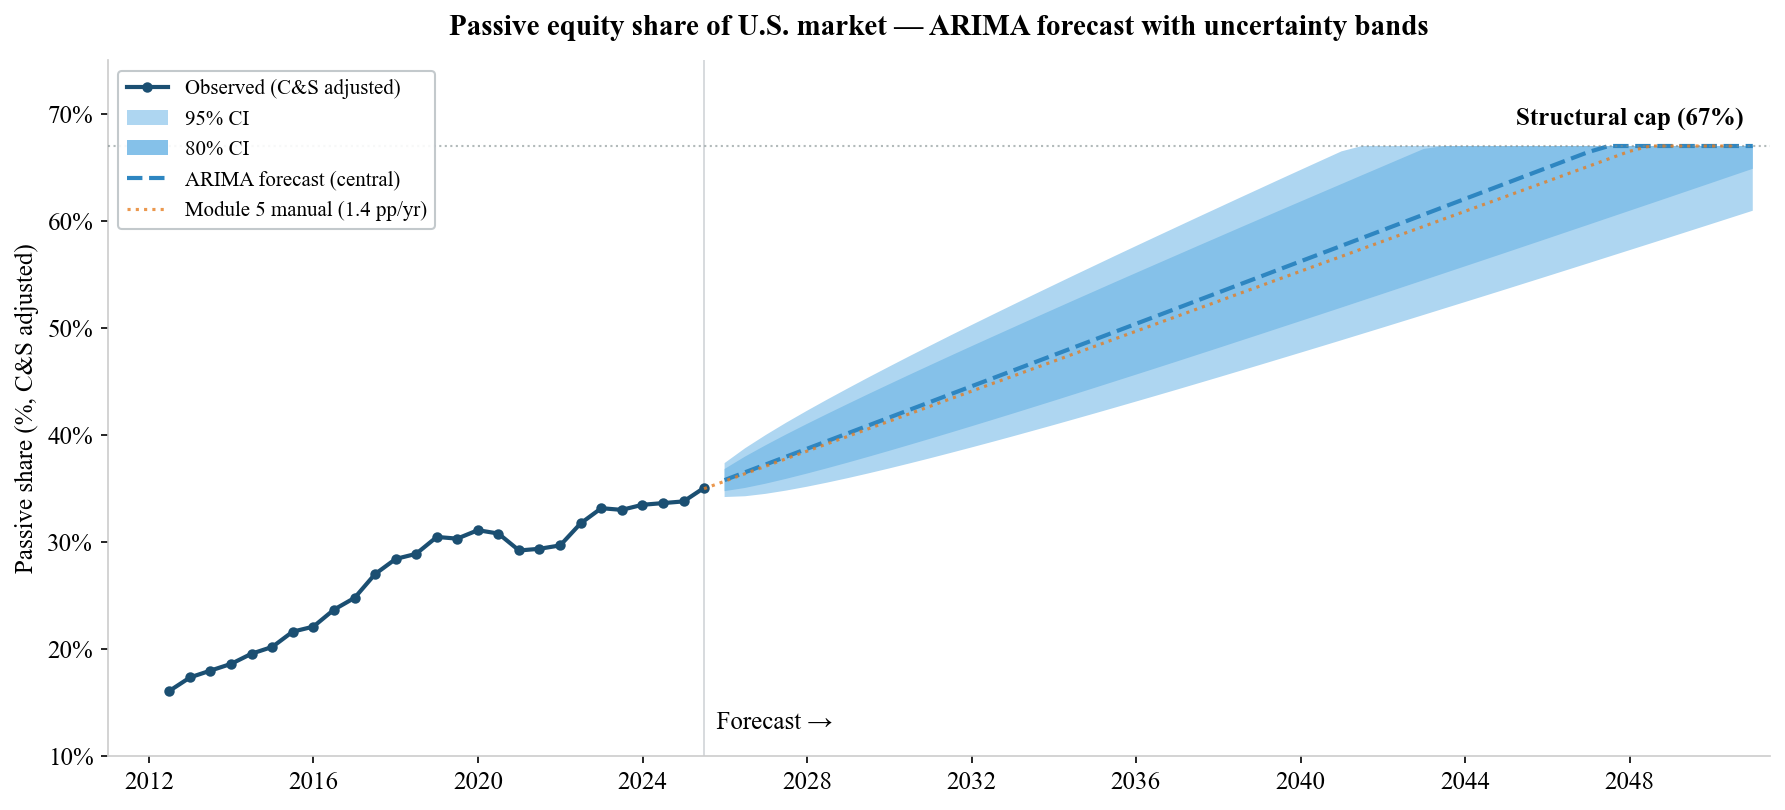


04_arima — COMPLETE
  Model:     ARIMA(0,1,0) with drift
  Obs:       27 semi-annual (2012-H1 to 2025-H1)
  Drift:     +0.4615 pp/half (+0.923 pp/year)
  Forecast:  51 steps (2025-H2 to 2050-H2)
  Cap:       67.0%
  Scaling:   ×1.58 (Chinco & Sammon 2024)

  Files exported:
    • arima_passive_share_forecast.csv (semi-annual, 51 rows)
    • arima_passive_share_annual.csv (annual H2 values, 26 rows)
    • arima_visual_inspection.png
    • arima_diagnostics.png
    • arima_passive_share_forecast.png

  → NEXT: 02_model.ipynb imports arima_passive_share_annual.csv
    for the time-varying multiplier (Haddad pass-through formula)


In [14]:
# ── Money Chart: Historical + Forecast with Fan Bands ────────────────────────
plt.rcParams['font.family'] = 'Times New Roman'

fig, ax = plt.subplots(figsize=(12, 5.5), facecolor='white')
ax.set_facecolor('white')

ax.plot(data.index, data['cs_adjusted_pct'], 'o-', color=PAL['navy'],
        markersize=4, linewidth=2, label='Observed (C&S adjusted)', zorder=5)

fc_dates_ts = pd.DatetimeIndex(forecast_df['date'])

ax.fill_between(fc_dates_ts, forecast_df['cs_lower_95'], forecast_df['cs_upper_95'],
                color='#AED6F1', label='95% CI', edgecolor='none')
ax.fill_between(fc_dates_ts, forecast_df['cs_lower_80'], forecast_df['cs_upper_80'],
                color='#85C1E9', label='80% CI', edgecolor='none')
ax.plot(fc_dates_ts, forecast_df['cs_narrow_pct'], '--', color=PAL['blue'],
        linewidth=2, label='ARIMA forecast (central)', zorder=5)

ax.axhline(y=PASSIVE_CAP, color=PAL['slate'], linestyle=':', linewidth=1, alpha=0.6, zorder=5)
ax.text(pd.Timestamp('2048-01-01'), PASSIVE_CAP + 2, f'Structural cap ({PASSIVE_CAP:.0f}%)',
        fontsize=12, fontweight='bold', color='black', ha='center')

ax.axvline(x=data.index[-1], color=PAL['silver'], linestyle='-', linewidth=0.8, alpha=0.7)
ax.text(data.index[-1], 12, '  Forecast →', fontsize=12, color='black', va='bottom')

manual_years = pd.date_range('2025-06-30', '2050-12-30', freq='6ME')
manual_path = np.minimum(35.0 + np.arange(len(manual_years)) * (1.4/2), PASSIVE_CAP)
ax.plot(manual_years[:len(manual_path)], manual_path, ':', color=PAL['amber'],
        linewidth=1.5, alpha=0.8, label='Module 5 manual (1.4 pp/yr)', zorder=5)

ax.set_title('Passive equity share of U.S. market — ARIMA forecast with uncertainty bands',
             fontsize=14, fontweight='bold', color='black', pad=12)
ax.set_ylabel('Passive share (%, C&S adjusted)', fontsize=12, color='black')
ax.set_xlabel('')
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax.set_ylim(10, 75)
ax.set_xlim(pd.Timestamp('2011-01-01'), pd.Timestamp('2051-06-01'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.tick_params(colors='black', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.grid(False)

plt.tight_layout()
plt.savefig(f'{OUT}\\arima_passive_share_forecast.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

drift = best_fit.params.get('drift', best_fit.params.get('x1', np.nan))
print(f"\n{'='*60}")
print(f'04_arima — COMPLETE')
print(f"{'='*60}")
print(f'  Model:     {selected} with drift')
print(f'  Obs:       {len(data)} semi-annual (2012-H1 to 2025-H1)')
print(f'  Drift:     {drift:+.4f} pp/half ({drift*2:+.3f} pp/year)')
print(f'  Forecast:  {N_STEPS} steps (2025-H2 to 2050-H2)')
print(f'  Cap:       {PASSIVE_CAP}%')
print(f'  Scaling:   ×{CS_SCALING} (Chinco & Sammon 2024)')
print(f'\n  Files exported:')
print(f'    • arima_passive_share_forecast.csv (semi-annual, {len(forecast_df)} rows)')
print(f'    • arima_passive_share_annual.csv (annual H2 values, {len(annual_export)} rows)')
print(f'    • arima_visual_inspection.png')
print(f'    • arima_diagnostics.png')
print(f'    • arima_passive_share_forecast.png')
print(f'\n  → NEXT: 02_model.ipynb imports arima_passive_share_annual.csv')
print(f'    for the time-varying multiplier (Haddad pass-through formula)')

In [10]:
arima = pd.read_csv(r'..\data\processed\arima_passive_share_annual.csv')
print(f'ARIMA columns: {list(arima.columns)}')
print(arima.head(3))

ARIMA columns: ['year', 'period', 'bb_narrow_pct', 'cs_narrow_pct', 'bb_lower_95', 'bb_upper_95', 'cs_lower_95', 'cs_upper_95']
   year   period  bb_narrow_pct  cs_narrow_pct  bb_lower_95  bb_upper_95  \
0  2025  2025-H2      22.661534      35.805223    21.659078    23.663989   
1  2026  2026-H2      23.584601      37.263669    21.848297    25.320905   
2  2027  2027-H2      24.507668      38.722116    22.266110    26.749227   

   cs_lower_95  cs_upper_95  
0    34.221344    37.389103  
1    34.520310    40.007029  
2    35.180454    42.263778  


## Appendix: Cap Comparison
Overlay 67% and 80% cap forecasts to show the cap only binds after ~2047.

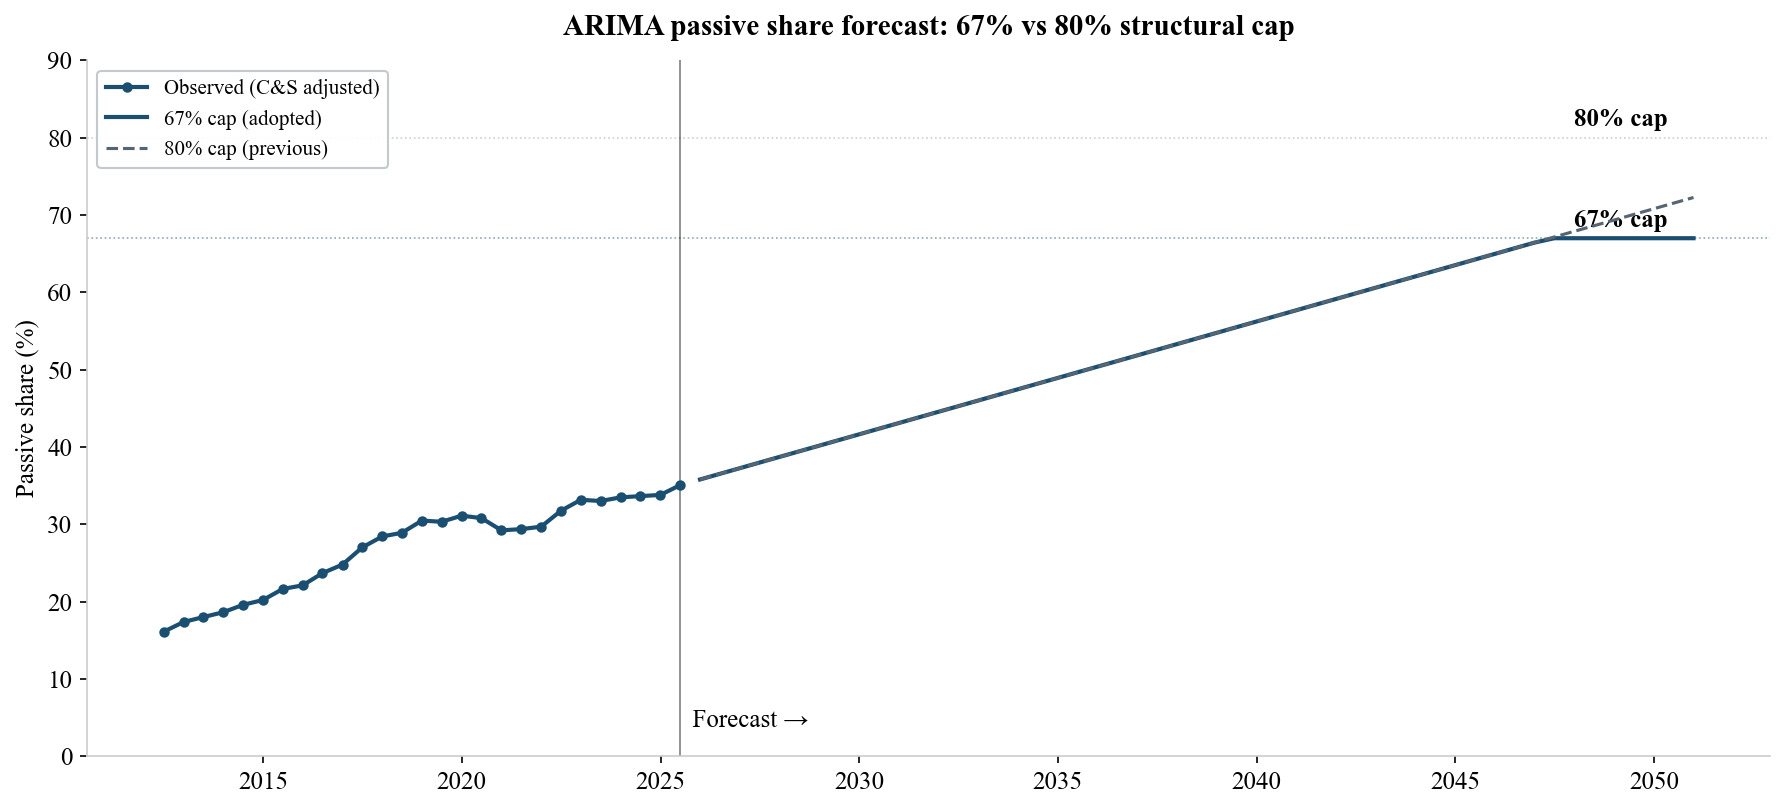

Cap comparison — key years:
  2030: 67% cap = 43.1%,  80% cap = 43.1%,  Δ = 0.0 pp
  2035: 67% cap = 50.4%,  80% cap = 50.4%,  Δ = 0.0 pp
  2040: 67% cap = 57.7%,  80% cap = 57.7%,  Δ = 0.0 pp
  2045: 67% cap = 65.0%,  80% cap = 65.0%,  Δ = 0.0 pp
  2050: 67% cap = 67.0%,  80% cap = 72.3%,  Δ = 5.3 pp

Forecasts diverge at ~2047: 67% cap binds at 67.0%, 80% cap still at 67.2%


In [15]:
# ── ITEM A10: 67% vs 80% Cap Comparison Chart ────────────────────────
plt.rcParams['font.family'] = 'Times New Roman'

fig, ax = plt.subplots(figsize=(12, 5.5), facecolor='white')
ax.set_facecolor('white')

# Historical (C&S adjusted)
ax.plot(data.index, data['cs_adjusted_pct'], 'o-', color=PAL['navy'],
        markersize=4, linewidth=2, label='Observed (C&S adjusted)', zorder=5)

fc_dates_ts = pd.DatetimeIndex(forecast_df['date'])

# Recompute uncapped forecast for comparison
fc_uncapped = best_fit.get_forecast(steps=N_STEPS).predicted_mean.values * CS_SCALING
fc_67_path = np.minimum(fc_uncapped, 67.0)
fc_80_path = np.minimum(fc_uncapped, 80.0)

ax.plot(fc_dates_ts, fc_67_path, '-', color=PAL['navy'], linewidth=2,
        label='67% cap (adopted)', zorder=5)
ax.plot(fc_dates_ts, fc_80_path, '--', color='#566573', linewidth=1.5,
        label='80% cap (previous)', zorder=5)

ax.axhline(y=67.0, color=PAL['navy'], linestyle=':', linewidth=0.8, alpha=0.5)
ax.axhline(y=80.0, color='#566573', linestyle=':', linewidth=0.8, alpha=0.3)
ax.text(pd.Timestamp('2048-01-01'), 68.5, '67% cap', fontsize=12,
        fontweight='bold', color='black')
ax.text(pd.Timestamp('2048-01-01'), 81.5, '80% cap', fontsize=12,
        fontweight='bold', color='black')

# Forecast divider
ax.axvline(x=data.index[-1], color='black', linestyle='-', linewidth=0.8, alpha=0.5)
ax.text(data.index[-1], 3, '  Forecast →', fontsize=12, color='black', va='bottom')

ax.set_title('ARIMA passive share forecast: 67% vs 80% structural cap',
             fontsize=14, fontweight='bold', color='black', pad=12)
ax.set_ylabel('Passive share (%)', fontsize=12, color='black')
ax.legend(loc='upper left', fontsize=10)
ax.set_ylim(0, 90)
ax.tick_params(colors='black', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.grid(False)

plt.tight_layout()
plt.savefig(f'{OUT}\\arima_cap_comparison.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

# Hard numbers
print('Cap comparison — key years:')
for t, date in enumerate(fc_dates_ts):
    yr = date.year
    if yr in [2030, 2035, 2040, 2045, 2050] and date.month > 6:
        print(f'  {yr}: 67% cap = {fc_67_path[t]:.1f}%,  80% cap = {fc_80_path[t]:.1f}%,  '
              f'Δ = {fc_80_path[t] - fc_67_path[t]:.1f} pp')

for t in range(len(fc_dates_ts)):
    if fc_67_path[t] < fc_80_path[t] - 0.1:
        print(f'\nForecasts diverge at ~{fc_dates_ts[t].year}: '
              f'67% cap binds at {fc_67_path[t]:.1f}%, 80% cap still at {fc_80_path[t]:.1f}%')
        break

In [12]:
# Check what variable holds the fitted ARIMA result
import statsmodels
# Try common names
for name in ['result', 'model_fit', 'fit', 'arima_fit', 'arima_result', 'res']:
    if name in dir():
        obj = eval(name)
        if hasattr(obj, 'resid'):
            print(f'Found: {name} has .resid')
            residuals = obj.resid
            rmse = (residuals**2).mean()**0.5
            print(f'ARIMA(0,1,0) residual RMSE: {rmse:.2f} pp')
            break

Found: fit has .resid
ARIMA(0,1,0) residual RMSE: 1.93 pp
